In [1]:
!pip install langdetect

# Standard libraries and progress bar
import re
from collections import Counter
from tqdm import tqdm

# Data manipulation and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# NLP and text processing
import chardet
import nltk
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from langdetect import detect, DetectorFactory
from langdetect.lang_detect_exception import LangDetectException

# Machine Learning: Preprocessing & Splitting
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

# Cross Validation
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Machine Learning: Models
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB

# Machine Learning: Evaluation Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, classification_report, confusion_matrix,
                             roc_curve, auc, precision_recall_curve)

# Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, loguniform

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 12.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=1fe610997249a54728a2ce1d54d310d784adbc418be13f5f499eba7f65aaa03b
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [ ]:
path = 'Dataset/Amazon-Product-Reviews - Amazon Product Review.csv'

df = pd.read_csv(path)

print("Columns:", df.columns.tolist())
display(df.head(3))

Columns: ['marketplace', 'customer_id', 'review_id', 'product_id', 'product_parent', 'product_title', 'product_category', 'star_rating', 'helpful_votes', 'total_votes', 'vine', 'verified_purchase', 'review_headline', 'review_body', 'review_date', 'sentiment']


,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date,sentiment
0,US,11555559,R1QXC7AHHJBQ3O,B00IKPX4GY,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,0,0,N,Y,Five Stars,Great love it,2015-08-31,1
1,US,31469372,R175VSRV6ZETOP,B00IKPYKWG,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,3,0,0,N,N,Lots of ads Slow processing speed Occasionally...,Lots of ads<br />Slow processing speed<br />Oc...,2015-08-31,0
2,US,26843895,R2HRFF78MWGY19,B00IKPW0UA,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,0,0,N,Y,Well thought out device,Excellent unit. The versatility of this table...,2015-08-31,1


In [3]:
# 1. Keep only the text and target columns to save memory
df = df[['review_body', 'sentiment']]

# 2. Rename columns to match the pipeline we already built
df = df.rename(columns={'review_body': 'Sentence', 'sentiment': 'Sentiment'})

# 3. Drop any rows where the review is missing and reset the index
df = df.dropna(subset=['Sentence']).reset_index(drop=True)

# Preview the clean starting point
print(f"New dataset shape: {df.shape}")
display(df.head(3))

New dataset shape: (30842, 2)


,Sentence,Sentiment
0,Great love it,1
1,Lots of ads<br />Slow processing speed<br />Oc...,0
2,Excellent unit. The versatility of this table...,1


# EDA & General Data Preprocessing

In [4]:
# Dataset shape
print("Dataset shape:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Column names
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (30842, 2)
Number of rows: 30842
Number of columns: 2

Columns:
['Sentence', 'Sentiment']


In [5]:
# Before removing nulls
null_summary = pd.DataFrame({
    'Null Count': df.isnull().sum(),
    'Null Percentage': df.isnull().mean() * 100
})
print("Before dropping nulls:")
print(null_summary)

df = df.dropna(subset=['Sentence'])

# After removing nulls
null_summary = pd.DataFrame({
    'Null Count': df.isnull().sum(),
    'Null Percentage': df.isnull().mean() * 100
})
print("Before dropping nulls:")
print(null_summary)

Before dropping nulls:
           Null Count  Null Percentage
Sentence            0              0.0
Sentiment           0              0.0
Before dropping nulls:
           Null Count  Null Percentage
Sentence            0              0.0
Sentiment           0              0.0


In [6]:
# Check duplicates based only on the Sentence column
duplicate_sentence_count = df.duplicated(subset=['Sentence']).sum()
print("Number of duplicate sentences:", duplicate_sentence_count)

# Show duplicated sentences
duplicate_sentences = df[df.duplicated(subset=['Sentence'], keep=False)]
print("\nDuplicated sentences:")
print(duplicate_sentences.sort_values(by='Sentence'))

# Drop duplicate sentences, keeping the first occurrence
df = df.drop_duplicates(subset=['Sentence'], keep='first')

# Reset the index to keep the dataframe clean
df = df.reset_index(drop=True)

print("Number of rows:", df.shape[0])


Number of duplicate sentences: 3081

Duplicated sentences:
      Sentence  Sentiment
20267       :)          1
24247       :)          1
18844       :)          1
20616       :)          1
20609       :D          1
...        ...        ...
12992       👍👍          1
13194        😁          1
10239        😁          1
4887         😃          1
27282        😃          1

[3591 rows x 2 columns]
Number of rows: 27761


Class counts:
Sentiment
0     5045
1    22716
Name: count, dtype: int64

Class percentages:
Sentiment
0    18.172976
1    81.827024
Name: proportion, dtype: float64


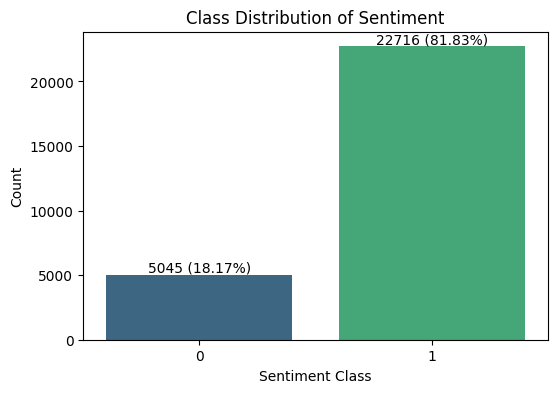

In [7]:
class_counts = df['Sentiment'].value_counts().sort_index()
class_percent = df['Sentiment'].value_counts(normalize=True).sort_index() * 100

print("Class counts:")
print(class_counts)
print("\nClass percentages:")
print(class_percent)

plt.figure(figsize=(6, 4))
ax = sns.countplot(
    data=df,
    x='Sentiment',
    hue='Sentiment',
    palette='viridis',
    legend=False
)

plt.title('Class Distribution of Sentiment')
plt.xlabel('Sentiment Class')
plt.ylabel('Count')

for i, count in enumerate(class_counts):
    percent = class_percent.iloc[i]
    ax.text(i, count + 200, f'{count} ({percent:.2f}%)', ha='center')

plt.show()

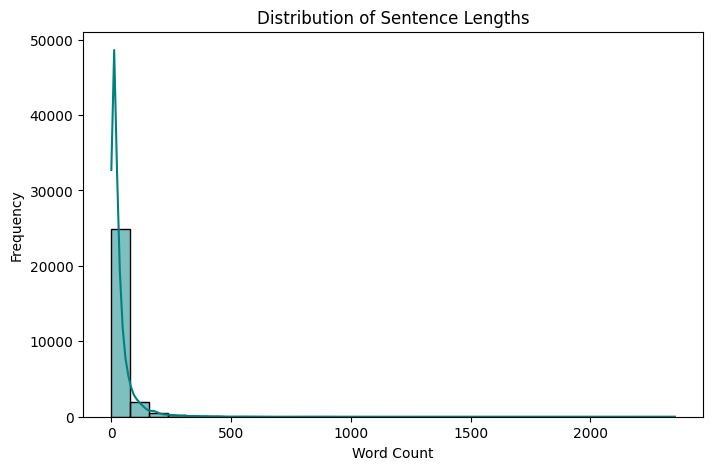

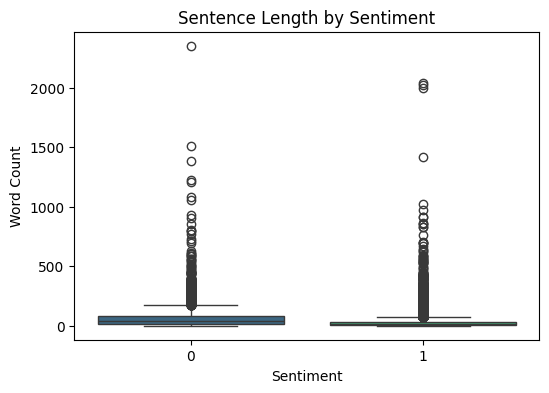

In [8]:
# Create sentence length feature
df['word_count'] = df['Sentence'].astype(str).apply(lambda x: len(x.split()))

# Histogram
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='word_count', bins=30, kde=True, color='teal')
plt.title('Distribution of Sentence Lengths')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

# Boxplot by sentiment
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Sentiment', y='word_count', hue='Sentiment', palette='viridis', legend=False)
plt.title('Sentence Length by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Word Count')
plt.show()

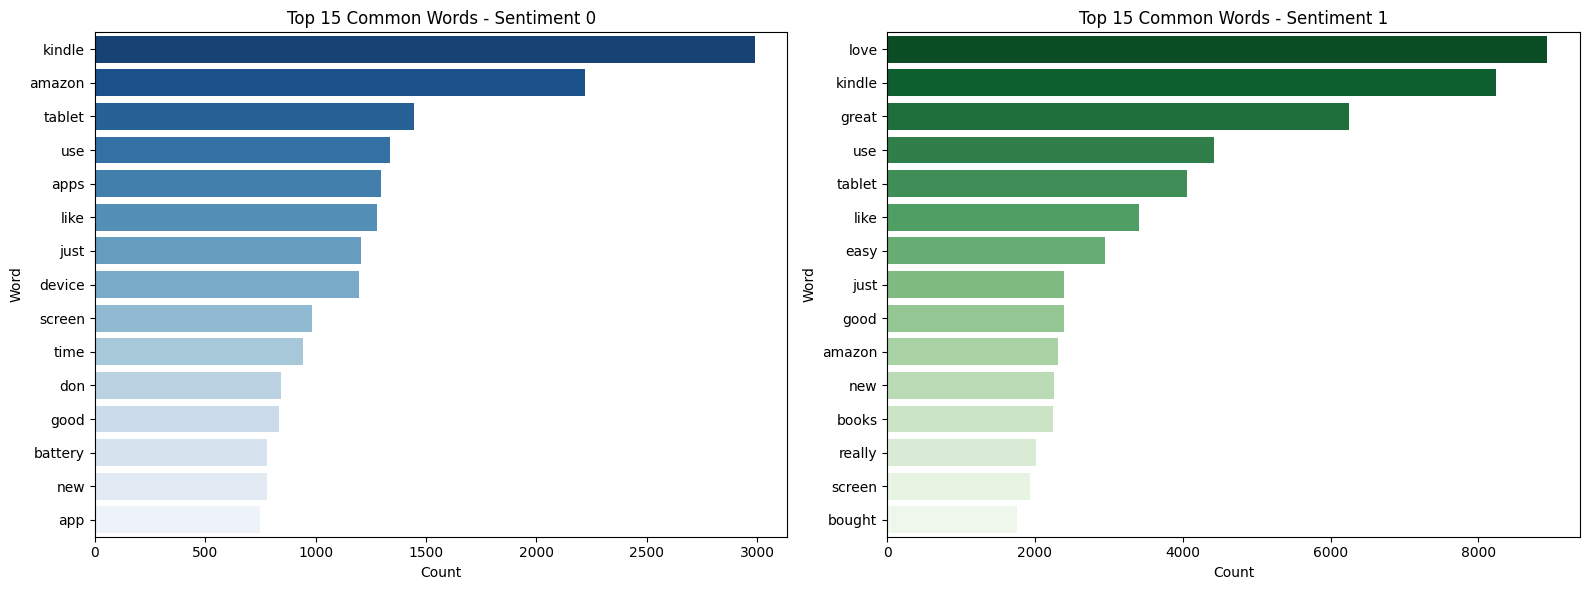

Top words for Sentiment 0
       Word  Count
0    kindle   2987
1    amazon   2220
2    tablet   1445
3       use   1338
4      apps   1296
5      like   1279
6      just   1204
7    device   1196
8    screen    982
9      time    943
10      don    844
11     good    835
12  battery    778
13      new    778
14      app    750

Top words for Sentiment 1
      Word  Count
0     love   8930
1   kindle   8241
2    great   6244
3      use   4419
4   tablet   4055
5     like   3415
6     easy   2949
7     just   2398
8     good   2391
9   amazon   2308
10     new   2256
11   books   2241
12  really   2019
13  screen   1929
14  bought   1761


In [9]:
stop_words = set(ENGLISH_STOP_WORDS)

def tokenize(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stop_words and len(word) > 2]
    return words

# Get words for each sentiment class
words_0 = []
for sentence in df[df['Sentiment'] == 0]['Sentence']:
    words_0.extend(tokenize(sentence))

words_1 = []
for sentence in df[df['Sentiment'] == 1]['Sentence']:
    words_1.extend(tokenize(sentence))

# Count top 15 words
top_0 = pd.DataFrame(Counter(words_0).most_common(15), columns=['Word', 'Count'])
top_1 = pd.DataFrame(Counter(words_1).most_common(15), columns=['Word', 'Count'])

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=top_0, x='Count', y='Word', ax=axes[0], hue='Word', palette='Blues_r', legend=False)
axes[0].set_title('Top 15 Common Words - Sentiment 0')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Word')

sns.barplot(data=top_1, x='Count', y='Word', ax=axes[1], hue='Word', palette='Greens_r', legend=False)
axes[1].set_title('Top 15 Common Words - Sentiment 1')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Word')

plt.tight_layout()
plt.show()

# print the tables
print("Top words for Sentiment 0")
print(top_0)

print("\nTop words for Sentiment 1")
print(top_1)


In [10]:
# Text quality checks
quality_summary = {
    'Total rows': len(df),
    'Null sentences': df['Sentence'].isnull().sum(),
    'Empty sentences': df['Sentence'].fillna('').str.strip().eq('').sum(),
    'Leading/trailing spaces': df['Sentence'].fillna('').str.contains(r'^\s|\s$', regex=True).sum(),
    'Multiple spaces': df['Sentence'].fillna('').str.contains(r'\s{2,}', regex=True).sum(),
    'Contains digits': df['Sentence'].fillna('').str.contains(r'\d', regex=True).sum(),
    'Contains special characters': df['Sentence'].fillna('').str.contains(r'[^A-Za-z0-9\s]', regex=True).sum(),
    'Contains URLs': df['Sentence'].fillna('').str.contains(r'http\S+|www\.\S+', regex=True, case=False).sum(),
    'Possible encoding issues': df['Sentence'].fillna('').str.contains(r'Ã|Â|â', regex=True).sum()
}

quality_df = pd.DataFrame(quality_summary.items(), columns=['Issue', 'Count'])
quality_df['Percentage'] = (quality_df['Count'] / len(df)) * 100

print("Text Quality Summary")
print(quality_df)

# Check unnecessary index column
if 'Unnamed: 0' in df.columns:
    print("\nColumn 'Unnamed: 0' detected. This is likely an extra index column and can be dropped.")

# Show sample rows with possible encoding issues
encoding_examples = df[df['Sentence'].fillna('').str.contains(r'Ã|Â|â', regex=True)][['Sentence']].head(5)
print("\nSample rows with possible encoding issues:")
print(encoding_examples)

# Show sample rows with extra spaces
space_examples = df[df['Sentence'].fillna('').str.contains(r'^\s|\s$|\s{2,}', regex=True)][['Sentence']].head(5)
print("\nSample rows with spacing issues:")
print(space_examples)

Text Quality Summary
                         Issue  Count  Percentage
0                   Total rows  27761  100.000000
1               Null sentences      0    0.000000
2              Empty sentences      0    0.000000
3      Leading/trailing spaces      0    0.000000
4              Multiple spaces   7996   28.802997
5              Contains digits   7070   25.467382
6  Contains special characters  25094   90.392997
7                Contains URLs      9    0.032420
8     Possible encoding issues      0    0.000000

Sample rows with possible encoding issues:
Empty DataFrame
Columns: [Sentence]
Index: []

Sample rows with spacing issues:
                                             Sentence
2   Excellent unit.  The versatility of this table...
3   I bought this on Amazon Prime so I ended up bu...
11  We have the old kindles but this one does a lo...
15  Just got it.  The promotional price was very g...
21  Don't waste your money buying a kindle fire hd...


In [11]:
# Drop the unnecessary index column
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Remove URLs using regex (replacing with a placeholder)
df['Sentence'] = df['Sentence'].str.replace(r'http\S+|www\.\S+', '<URL>', regex=True, case=False)

# Create the mask for Mojibake/encoding issues
encoding_mask = df['Sentence'].str.contains(r'Ã|Â|â', regex=True, na=False)

# Print the exact number of corrupted rows found
corrupted_count = encoding_mask.sum()
print(f"Number of corrupted rows found: {corrupted_count}")

# Drop the corrupted rows
df = df[~encoding_mask]

# Drop rows with Mojibake/encoding issues (added na=False)
encoding_mask = df['Sentence'].str.contains(r'Ã|Â|â', regex=True, na=False)
df = df[~encoding_mask]

# Reset index after dropping rows
df = df.reset_index(drop=True)

print("Number of rows:", df.shape[0])


Number of corrupted rows found: 0
Number of rows: 27761


In [12]:
# Re-run text quality checks to verify cleaning
quality_summary_post = {
    'Total rows': len(df),
    'Null sentences': df['Sentence'].isnull().sum(),
    'Empty sentences': df['Sentence'].fillna('').str.strip().eq('').sum(),
    'Leading/trailing spaces': df['Sentence'].fillna('').str.contains(r'^\s|\s$', regex=True).sum(),
    'Multiple spaces': df['Sentence'].fillna('').str.contains(r'\s{2,}', regex=True).sum(),
    'Contains digits': df['Sentence'].fillna('').str.contains(r'\d', regex=True).sum(),
    'Contains special characters': df['Sentence'].fillna('').str.contains(r'[^A-Za-z0-9\s]', regex=True).sum(),
    'Contains URLs': df['Sentence'].fillna('').str.contains(r'http\S+|www\.\S+', regex=True, case=False).sum(),
    'Possible encoding issues': df['Sentence'].fillna('').str.contains(r'Ã|Â|â', regex=True).sum()
}

quality_df_post = pd.DataFrame(quality_summary_post.items(), columns=['Issue', 'Count'])
quality_df_post['Percentage'] = (quality_df_post['Count'] / len(df)) * 100

print("Text Quality Summary (Post-Cleaning)")
print(quality_df_post)
print("\nCurrent Dataset Shape:", df.shape)

Text Quality Summary (Post-Cleaning)
                         Issue  Count  Percentage
0                   Total rows  27761  100.000000
1               Null sentences      0    0.000000
2              Empty sentences      0    0.000000
3      Leading/trailing spaces      0    0.000000
4              Multiple spaces   7996   28.802997
5              Contains digits   7068   25.460178
6  Contains special characters  25094   90.392997
7                Contains URLs      0    0.000000
8     Possible encoding issues      0    0.000000

Current Dataset Shape: (27761, 3)


# NLP Pipeline

## 1. Detecting Character / Encoding

In [13]:
# Detect Character / Encoding
with open(path, 'rb') as rawdata:
    result = chardet.detect(rawdata.read(10000))

print(f"Detected Encoding: {result['encoding']} (Confidence: {result['confidence']*100}%)")

Detected Encoding: Windows-1252 (Confidence: 72.84589867310012%)


## 2. Detecting Language

In [14]:
# Initialize the progress bar for pandas
tqdm.pandas(desc="Detecting language")

# Set seed for consistent results
DetectorFactory.seed = 0 

def detect_english(text):
    if not isinstance(text, str):
        return False
    try:
        return detect(text) == 'en'
    except LangDetectException:
        return False

# Detect Language
print("Detecting language for each sentence...")
is_english_mask = df['Sentence'].progress_apply(detect_english)

# Verification
print(f"\nFound {(~is_english_mask).sum()} non-English rows. Here are 30 samples:")
pd.set_option('display.max_colwidth', None)
display(df[~is_english_mask][['Sentence']].head(30))

print(f"\nDataset remains untouched. Total rows: {len(df)}")

Detecting language for each sentence...


Detecting language: 100%|██████████| 27761/27761 [01:30<00:00, 306.32it/s]


Found 1386 non-English rows. Here are 30 samples:


,Sentence
9,Made well. Like looks and style
12,Great product
14,great
61,Fantastic!😯
66,love it
77,i returned item
80,💛💛💛
92,Excellent
101,Amazing!
108,I love Kindle! Works great!



Dataset remains untouched. Total rows: 27761


Above proved that the 1386 sentences (Sample) are actually English. Therefore, no "Dropping" or "Translation" will be done.

In [15]:
print("Number of rows:", df.shape[0])


Number of rows: 27761


## 3. Lowercasing Sentences

In [16]:
def convert_to_lowercase(text):
    return str(text).lower()

# Creating a new column to safely compare the before and after
df['Lower_Sentence'] = df['Sentence'].apply(convert_to_lowercase)

# Verify the transformation
pd.set_option('display.max_colwidth', None)
display(df[['Sentence', 'Lower_Sentence']].head(10))

,Sentence,Lower_Sentence
0,Great love it,great love it
1,Lots of ads<br />Slow processing speed<br />Occasionally shuts down apps<br />WIFI keeps having authentication issues<br /><br />Was cheap for a tablet and now i know why.,lots of ads<br />slow processing speed<br />occasionally shuts down apps<br />wifi keeps having authentication issues<br /><br />was cheap for a tablet and now i know why.
2,"Excellent unit. The versatility of this tablet, besides being competitively priced is a solution to the elderly. Poor eyesight and physical disabilities associated with age and using the supporting add on features allows the user to stay in touch with our changing world.<br />A realistic add on keyboard that you can see and use.<br />I cannot wait to use my Fire HD7 to show computer created work sheets and class instructions to my students. (HMDI) Good by to copiers and reams of paper, Farwell to those costly printer inks!<br /><br />Oh yes I have much more to gain back. Just takes a little effort to learn more, open a book and read.<br />Noel","excellent unit. the versatility of this tablet, besides being competitively priced is a solution to the elderly. poor eyesight and physical disabilities associated with age and using the supporting add on features allows the user to stay in touch with our changing world.<br />a realistic add on keyboard that you can see and use.<br />i cannot wait to use my fire hd7 to show computer created work sheets and class instructions to my students. (hmdi) good by to copiers and reams of paper, farwell to those costly printer inks!<br /><br />oh yes i have much more to gain back. just takes a little effort to learn more, open a book and read.<br />noel"
3,I bought this on Amazon Prime so I ended up buying the 16gb one for $95. The camera is okay and I love the edit features you can do to the pictures. Amazon/Netflix/Huliu all run smoothly on this tablet. The internet runs a lot faster than our other tablet too. While over all I am happy with this tablet it did come with a couple disappointments that I wanted to make sure other people are aware of. I am an Amazon Prime member and I thought that with Amazon Prime you could read a lot of books for free with a kindle and was disappointed to see you can only borrow one kindle book a month for free. :( Also one of the main reasons we purchased a tablet was because my kids love the Plants vs Zombies games. The kids were quite disappointed that Plants vs Zombies 2 is not available for the fire. There are also other games/apps that we were looking forward to using that are not available on the Fire that were available for our previous cheaper Neutab tablet that we were looking forward to using on this tablet. I recommend people ask about apps they are looking forward to using before buying.,i bought this on amazon prime so i ended up buying the 16gb one for $95. the camera is okay and i love the edit features you can do to the pictures. amazon/netflix/huliu all run smoothly on this tablet. the internet runs a lot faster than our other tablet too. while over all i am happy with this tablet it did come with a couple disappointments that i wanted to make sure other people are aware of. i am an amazon prime member and i thought that with amazon prime you could read a lot of books for free with a kindle and was disappointed to see you can only borrow one kindle book a month for free. :( also one of the main reasons we purchased a tablet was because my kids love the plants vs zombies games. the kids were quite disappointed that plants vs zombies 2 is not available for the fire. there are also other games/apps that we were looking forward to using that are not available on the fire that were available for our previous cheaper neutab tablet that we were looking forward to using on this tablet. i recommend people ask about apps they are looking forward to using before buying.
4,All Amazon products continue to meet my expectations,all amazon products continue to meet

## 4. Removing Punctuations

In [17]:
# Removing Punctuations
def remove_punctuation(text):
    # Replace anything that is not a lowercase letter (a-z) or whitespace with a space
    clean_text = re.sub(r'[^a-z\s]', ' ', str(text))
    # Collapse multiple consecutive spaces into a single space
    return re.sub(r'\s+', ' ', clean_text).strip()

# Apply the regex filter
df['NoPunct_Sentence'] = df['Lower_Sentence'].apply(remove_punctuation)

# Verify the transformation
display(df[['Lower_Sentence', 'NoPunct_Sentence']].head(10))

,Lower_Sentence,NoPunct_Sentence
0,great love it,great love it
1,lots of ads<br />slow processing speed<br />occasionally shuts down apps<br />wifi keeps having authentication issues<br /><br />was cheap for a tablet and now i know why.,lots of ads br slow processing speed br occasionally shuts down apps br wifi keeps having authentication issues br br was cheap for a tablet and now i know why
2,"excellent unit. the versatility of this tablet, besides being competitively priced is a solution to the elderly. poor eyesight and physical disabilities associated with age and using the supporting add on features allows the user to stay in touch with our changing world.<br />a realistic add on keyboard that you can see and use.<br />i cannot wait to use my fire hd7 to show computer created work sheets and class instructions to my students. (hmdi) good by to copiers and reams of paper, farwell to those costly printer inks!<br /><br />oh yes i have much more to gain back. just takes a little effort to learn more, open a book and read.<br />noel",excellent unit the versatility of this tablet besides being competitively priced is a solution to the elderly poor eyesight and physical disabilities associated with age and using the supporting add on features allows the user to stay in touch with our changing world br a realistic add on keyboard that you can see and use br i cannot wait to use my fire hd to show computer created work sheets and class instructions to my students hmdi good by to copiers and reams of paper farwell to those costly printer inks br br oh yes i have much more to gain back just takes a little effort to learn more open a book and read br noel
3,i bought this on amazon prime so i ended up buying the 16gb one for $95. the camera is okay and i love the edit features you can do to the pictures. amazon/netflix/huliu all run smoothly on this tablet. the internet runs a lot faster than our other tablet too. while over all i am happy with this tablet it did come with a couple disappointments that i wanted to make sure other people are aware of. i am an amazon prime member and i thought that with amazon prime you could read a lot of books for free with a kindle and was disappointed to see you can only borrow one kindle book a month for free. :( also one of the main reasons we purchased a tablet was because my kids love the plants vs zombies games. the kids were quite disappointed that plants vs zombies 2 is not available for the fire. there are also other games/apps that we were looking forward to using that are not available on the fire that were available for our previous cheaper neutab tablet that we were looking forward to using on this tablet. i recommend people ask about apps they are looking forward to using before buying.,i bought this on amazon prime so i ended up buying the gb one for the camera is okay and i love the edit features you can do to the pictures amazon netflix huliu all run smoothly on this tablet the internet runs a lot faster than our other tablet too while over all i am happy with this tablet it did come with a couple disappointments that i wanted to make sure other people are aware of i am an amazon prime member and i thought that with amazon prime you could read a lot of books for free with a kindle and was disappointed to see you can only borrow one kindle book a month for free also one of the main reasons we purchased a tablet was because my kids love the plants vs zombies games the kids were quite disappointed that plants vs zombies is not available for the fire there are also other games apps that we were looking forward to using that are not available on the fire that were available for our previous cheaper neutab tablet that we were looking forward to using on this tablet i recommend people ask about apps they are looking forward to using before buying
4,all amazon products continue to meet my expectations,all amazon products continue to meet my expectations
5,good product. i like it 😀,good pr

## 5. Tokenization

In [18]:
# Download the necessary NLTK tokenizer data
nltk.download('punkt', quiet=True)

# Define the tokenization function
def tokenize_sentence(text):
    return word_tokenize(text)

# Apply tokenization to the cleaned sentences
df['Tokenized_Sentence'] = df['NoPunct_Sentence'].apply(tokenize_sentence)

# Verify the transformation
pd.set_option('display.max_colwidth', None)
display(df[['NoPunct_Sentence', 'Tokenized_Sentence']].head())

,NoPunct_Sentence,Tokenized_Sentence
0,great love it,"[great, love, it]"
1,lots of ads br slow processing speed br occasionally shuts down apps br wifi keeps having authentication issues br br was cheap for a tablet and now i know why,"[lots, of, ads, br, slow, processing, speed, br, occasionally, shuts, down, apps, br, wifi, keeps, having, authentication, issues, br, br, was, cheap, for, a, tablet, and, now, i, know, why]"
2,excellent unit the versatility of this tablet besides being competitively priced is a solution to the elderly poor eyesight and physical disabilities associated with age and using the supporting add on features allows the user to stay in touch with our changing world br a realistic add on keyboard that you can see and use br i cannot wait to use my fire hd to show computer created work sheets and class instructions to my students hmdi good by to copiers and reams of paper farwell to those costly printer inks br br oh yes i have much more to gain back just takes a little effort to learn more open a book and read br noel,"[excellent, unit, the, versatility, of, this, tablet, besides, being, competitively, priced, is, a, solution, to, the, elderly, poor, eyesight, and, physical, disabilities, associated, with, age, and, using, the, supporting, add, on, features, allows, the, user, to, stay, in, touch, with, our, changing, world, br, a, realistic, add, on, keyboard, that, you, can, see, and, use, br, i, can, not, wait, to, use, my, fire, hd, to, show, computer, created, work, sheets, and, class, instructions, to, my, students, hmdi, good, by, to, copiers, and, reams, of, paper, farwell, to, those, costly, printer, inks, br, br, oh, yes, i, have, much, more, ...]"
3,i bought this on amazon prime so i ended up buying the gb one for the camera is okay and i love the edit features you can do to the pictures amazon netflix huliu all run smoothly on this tablet the internet runs a lot faster than our other tablet too while over all i am happy with this tablet it did come with a couple disappointments that i wanted to make sure other people are aware of i am an amazon prime member and i thought that with amazon prime you could read a lot of books for free with a kindle and was disappointed to see you can only borrow one kindle book a month for free also one of the main reasons we purchased a tablet was because my kids love the plants vs zombies games the kids were quite disappointed that plants vs zombies is not available for the fire there are also other games apps that we were looking forward to using that are not available on the fire that were available for our previous cheaper neutab tablet that we were looking forward to using on this tablet i recommend people ask about apps they are looking forward to using before buying,"[i, bought, this, on, amazon, prime, so, i, ended, up, buying, the, gb, one, for, the, camera, is, okay, and, i, love, the, edit, features, you, can, do, to, the, pictures, amazon, netflix, huliu, all, run, smoothly, on, this, tablet, the, internet, runs, a, lot, faster, than, our, other, tablet, too, while, over, all, i, am, happy, with, this, tablet, it, did, come, with, a, couple, disappointments, that, i, wanted, to, make, sure, other, people, are, aware, of, i, am, an, amazon, prime, member, and, i, thought, that, with, amazon, prime, you, could, read, a, lot, of, books, for, free, ...]"
4,all amazon products continue to meet my expectations,"[all, amazon, products, continue, to, meet, my, expectations]"


## 6. Stop Word Removal

In [19]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# 1. Convert scikit-learn's frozen set into a normal, editable set
custom_stop_words = set(ENGLISH_STOP_WORDS)

# 2. Define the negation words we  want to keep for sentiment
negations_to_keep = {'no', 'not', 'nor', 'none', 'nothing', 'never', 'cannot', 'neither'}

# 3. Remove these negations from the stop words list
custom_stop_words = custom_stop_words - negations_to_keep

print(f"Original stop words: {len(ENGLISH_STOP_WORDS)}")
print(f"Custom stop words: {len(custom_stop_words)}")

# 4. Update the function to use the new list AND save the negation words
def remove_custom_stopwords(token_list):
    # Keep the word if it is NOT a stop word AND (it is longer than 2 chars OR it is one of our negations)
    return [word for word in token_list 
            if word not in custom_stop_words and (len(word) > 2 or word in negations_to_keep)]

# 5. Apply to your existing 'Tokenized_Sentence' column
print("\nRemoving Stopwords but keeping negations...")
df['NoStopWords_Sentence'] = df['Tokenized_Sentence'].apply(remove_custom_stopwords)

# Preview the change
display(df[['Tokenized_Sentence', 'NoStopWords_Sentence']].head(2))

Original stop words: 318
Custom stop words: 310

Removing Stopwords but keeping negations...


,Tokenized_Sentence,NoStopWords_Sentence
0,"[great, love, it]","[great, love]"
1,"[lots, of, ads, br, slow, processing, speed, br, occasionally, shuts, down, apps, br, wifi, keeps, having, authentication, issues, br, br, was, cheap, for, a, tablet, and, now, i, know, why]","[lots, ads, slow, processing, speed, occasionally, shuts, apps, wifi, keeps, having, authentication, issues, cheap, tablet, know]"


## 7. POS-Tagging

In [20]:
# Download required NLTK data for tagging
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

tqdm.pandas(desc="POS Tagging")

def apply_pos_tags(token_list):
    # Assigns a grammatical tag to each word
    return nltk.pos_tag(token_list)

print("Applying POS Tags...")
df['POS_Tagged_Sentence'] = df['NoStopWords_Sentence'].progress_apply(apply_pos_tags)

# Preview the change
display(df[['NoStopWords_Sentence', 'POS_Tagged_Sentence']].head(3))

Applying POS Tags...


POS Tagging: 100%|██████████| 27761/27761 [00:21<00:00, 1297.87it/s]


,NoStopWords_Sentence,POS_Tagged_Sentence
0,"[great, love]","[(great, JJ), (love, NN)]"
1,"[lots, ads, slow, processing, speed, occasionally, shuts, apps, wifi, keeps, having, authentication, issues, cheap, tablet, know]","[(lots, NNS), (ads, NNS), (slow, VBP), (processing, VBG), (speed, NN), (occasionally, RB), (shuts, VBZ), (apps, JJ), (wifi, NN), (keeps, NNS), (having, VBG), (authentication, NN), (issues, NNS), (cheap, JJ), (tablet, NN), (know, VB)]"
2,"[excellent, unit, versatility, tablet, competitively, priced, solution, elderly, poor, eyesight, physical, disabilities, associated, age, using, supporting, add, features, allows, user, stay, touch, changing, world, realistic, add, keyboard, use, not, wait, use, computer, created, work, sheets, class, instructions, students, hmdi, good, copiers, reams, paper, farwell, costly, printer, inks, yes, gain, just, takes, little, effort, learn, open, book, read, noel]","[(excellent, JJ), (unit, NN), (versatility, NN), (tablet, NN), (competitively, RB), (priced, VBN), (solution, NN), (elderly, JJ), (poor, JJ), (eyesight, JJ), (physical, JJ), (disabilities, NNS), (associated, VBN), (age, NN), (using, VBG), (supporting, VBG), (add, NN), (features, NNS), (allows, VBZ), (user, JJ), (stay, NN), (touch, RB), (changing, VBG), (world, NN), (realistic, JJ), (add, NN), (keyboard, NN), (use, IN), (not, RB), (wait, VBN), (use, NN), (computer, NN), (created, VBD), (work, NN), (sheets, NNS), (class, NN), (instructions, NNS), (students, NNS), (hmdi, VBP), (good, JJ), (copiers, NNS), (reams, VBP), (paper, NN), (farwell, NN), (costly, JJ), (printer, JJ), (inks, NNS), (yes, RB), (gain, VB), (just, RB), (takes, VBZ), (little, JJ), (effort, NN), (learn, VBD), (open, JJ), (book, NN), (read, VBD), (noel, JJ)]"


## 8. Lemmatization

In [21]:
# Download required NLTK data for lemmatization
nltk.download('wordnet', quiet=True)

lemmatizer = WordNetLemmatizer()
tqdm.pandas(desc="Lemmatizing")

def get_wordnet_pos(treebank_tag):
    # Maps NLTK tags to WordNet tags
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN 

def lemmatize_tagged_tokens(tagged_list):
    # Lemmatizes based on the POS tag and joins back into a string
    cleaned_tokens = []
    for word, tag in tagged_list:
        wn_tag = get_wordnet_pos(tag)
        lemma = lemmatizer.lemmatize(word, pos=wn_tag)
        cleaned_tokens.append(lemma)
            
    return " ".join(cleaned_tokens)

print("Lemmatizing...")
df['Processed_Sentence'] = df['POS_Tagged_Sentence'].progress_apply(lemmatize_tagged_tokens)

# Verify the final output
pd.set_option('display.max_colwidth', None)
display(df[['POS_Tagged_Sentence', 'Processed_Sentence']].head(5))

Lemmatizing...


Lemmatizing: 100%|██████████| 27761/27761 [00:05<00:00, 5078.27it/s] 


,POS_Tagged_Sentence,Processed_Sentence
0,"[(great, JJ), (love, NN)]",great love
1,"[(lots, NNS), (ads, NNS), (slow, VBP), (processing, VBG), (speed, NN), (occasionally, RB), (shuts, VBZ), (apps, JJ), (wifi, NN), (keeps, NNS), (having, VBG), (authentication, NN), (issues, NNS), (cheap, JJ), (tablet, NN), (know, VB)]",lot ad slow process speed occasionally shut apps wifi keep have authentication issue cheap tablet know
2,"[(excellent, JJ), (unit, NN), (versatility, NN), (tablet, NN), (competitively, RB), (priced, VBN), (solution, NN), (elderly, JJ), (poor, JJ), (eyesight, JJ), (physical, JJ), (disabilities, NNS), (associated, VBN), (age, NN), (using, VBG), (supporting, VBG), (add, NN), (features, NNS), (allows, VBZ), (user, JJ), (stay, NN), (touch, RB), (changing, VBG), (world, NN), (realistic, JJ), (add, NN), (keyboard, NN), (use, IN), (not, RB), (wait, VBN), (use, NN), (computer, NN), (created, VBD), (work, NN), (sheets, NNS), (class, NN), (instructions, NNS), (students, NNS), (hmdi, VBP), (good, JJ), (copiers, NNS), (reams, VBP), (paper, NN), (farwell, NN), (costly, JJ), (printer, JJ), (inks, NNS), (yes, RB), (gain, VB), (just, RB), (takes, VBZ), (little, JJ), (effort, NN), (learn, VBD), (open, JJ), (book, NN), (read, VBD), (noel, JJ)]",excellent unit versatility tablet competitively price solution elderly poor eyesight physical disability associate age use support add feature allow user stay touch change world realistic add keyboard use not wait use computer create work sheet class instruction student hmdi good copier ream paper farwell costly printer ink yes gain just take little effort learn open book read noel
3,"[(bought, VBN), (amazon, JJ), (prime, NN), (ended, VBD), (buying, NN), (camera, NN), (okay, NN), (love, VB), (edit, NN), (features, NNS), (pictures, VBZ), (amazon, JJ), (netflix, RB), (huliu, JJ), (run, VBP), (smoothly, RB), (tablet, JJ), (internet, NN), (runs, NNS), (lot, VBP), (faster, JJR), (tablet, NN), (happy, JJ), (tablet, NN), (did, VBD), (come, JJ), (couple, NN), (disappointments, NNS), (wanted, VBD), (make, JJ), (sure, JJ), (people, NNS), (aware, JJ), (amazon, JJ), (prime, JJ), (member, NN), (thought, VBN), (amazon, RB), (prime, JJ), (read, NN), (lot, NN), (books, NNS), (free, JJ), (kindle, NN), (disappointed, VBD), (borrow, JJ), (kindle, JJ), (book, NN), (month, NN), (free, JJ), (main, JJ), (reasons, NNS), (purchased, VBD), (tablet, NN), (kids, NNS), (love, VBD), (plants, NNS), (zombies, NNS), (games, NNS), (kids, NNS), (quite, RB), (disappointed, JJ), (plants, NNS), (zombies, VBZ), (not, RB), (available, JJ), (games, NNS), (apps, VBP), (looking, VBG), (forward, RB), (using, VBG), (not, RB), (available, JJ), (available, JJ), (previous, JJ), (cheaper, JJR), (neutab, NN), (tablet, NN), (looking, VBG), (forward, RB), (using, VBG), (tablet, JJ), (recommend, NN), (people, NNS), (ask, VBP), (apps, IN), (looking, VBG), (forward, RB), (using, VBG), (buying, VBG)]",buy amazon prime end buying camera okay love edit feature picture amazon netflix huliu run smoothly tablet internet run lot fast tablet happy tablet do come couple disappointment want make sure people aware amazon prime member think amazon prime read lot book free kindle disappoint borrow kindle book month free main reason purchase tablet kid love plant zombie game kid quite disappointed plant zombies not available game apps look forward use not available available previous cheap neutab tablet look forward use tablet recommend people ask apps look forward use buy
4,"[(amazon, NN), (products, NNS), (continue, VBP), (meet, NN), (expectations, NNS)]",amazon product continue meet expectation


## 9. Train/Test Dataset Split

In [22]:
# split the data to use the updated 'Processed_Sentence'
X = df['Processed_Sentence']
y = df['Sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Initialize Vectorizer
vectorizer = TfidfVectorizer(ngram_range=(1, 3), max_features=10000)

# Fit on Train, Transform on Train and Test
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"Training set shape: X={X_train_vec.shape}, y={y_train.shape}")
print(f"Test set shape: X={X_test_vec.shape}, y={y_test.shape}")

Training set shape: X=(22208, 10000), y=(22208,)
Test set shape: X=(5553, 10000), y=(5553,)


## 10. Cross Validation

In [23]:
# 1. Define the models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Linear SVM': LinearSVC(random_state=42, class_weight='balanced', max_iter=2000),
    'Complement NB': ComplementNB(),
    'SGD Classifier': SGDClassifier(random_state=42, class_weight='balanced', max_iter=1000)
}

# 2. Setup Stratified 5-Fold to maintain the 82/18 class ratio (Automatically will handle the 82/18 ratio)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Run Cross-Validation strictly on training data in order to prevent memorization by the model.
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_vec, y_train, cv=skf, scoring='f1_macro', n_jobs=-1)
    print(f"--- {name} Cross-Validation ---")
    print(f"F1 Macro Scores (5 folds): {np.round(cv_scores, 4)}")
    print(f"Mean F1 Macro: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})\n")

--- Logistic Regression Cross-Validation ---
F1 Macro Scores (5 folds): [0.8176 0.8241 0.8203 0.8233 0.8123]
Mean F1 Macro: 0.8195 (+/- 0.0085)

--- Linear SVM Cross-Validation ---
F1 Macro Scores (5 folds): [0.801  0.8065 0.8179 0.8219 0.8015]
Mean F1 Macro: 0.8098 (+/- 0.0172)

--- Complement NB Cross-Validation ---
F1 Macro Scores (5 folds): [0.7938 0.8041 0.8019 0.7991 0.7911]
Mean F1 Macro: 0.7980 (+/- 0.0097)

--- SGD Classifier Cross-Validation ---
F1 Macro Scores (5 folds): [0.8138 0.8278 0.8293 0.8243 0.8131]
Mean F1 Macro: 0.8217 (+/- 0.0138)



**With the result above, the choice of these 4 models are justified since they perform decently on all 5 different splits of the dataset.**

## 11. Logistic Regression Model

In [24]:
# 1. Train the Model
print("Training Logistic Regression model...")
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train_vec, y_train)

# 2. Predict on both Test and Train sets
print("Generating predictions...")
y_pred_test_lr = lr_model.predict(X_test_vec)
y_pred_train_lr = lr_model.predict(X_train_vec)

# 3. Calculate Accuracies
test_accuracy_lr = accuracy_score(y_test, y_pred_test_lr)
train_accuracy_lr = accuracy_score(y_train, y_pred_train_lr)

# 4. Display Test Performance
print("\n--- Logistic Regression Test Performance ---")
print(f"Overall Test Accuracy: {test_accuracy_lr:.4f}\n")

print("Classification Report (Focus on Class 0):")
print(classification_report(y_test, y_pred_test_lr))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_test_lr))

# 5. Display Overfitting Check
print("\n--- Logistic Regression Overfitting Check ---")
print(f"Training Accuracy: {train_accuracy_lr:.4f}")
print(f"Testing Accuracy:  {test_accuracy_lr:.4f}")
difference_lr = train_accuracy_lr - test_accuracy_lr
print(f"Difference:        {difference_lr:.4f}")

if difference_lr > 0.10:
    print("Conclusion: High Overfitting. The model memorized the training data.")
elif difference_lr > 0.03:
    print("Conclusion: Slight Overfitting. The model is slightly biased toward the training data.")
else:
    print("Conclusion: Good Generalization. No major overfitting.")

Training Logistic Regression model...
Generating predictions...

--- Logistic Regression Test Performance ---
Overall Test Accuracy: 0.8806

Classification Report (Focus on Class 0):
              precision    recall  f1-score   support

           0       0.62      0.86      0.72      1009
           1       0.97      0.89      0.92      4544

    accuracy                           0.88      5553
   macro avg       0.80      0.87      0.82      5553
weighted avg       0.90      0.88      0.89      5553

Confusion Matrix:
[[ 867  142]
 [ 521 4023]]

--- Logistic Regression Overfitting Check ---
Training Accuracy: 0.9065
Testing Accuracy:  0.8806
Difference:        0.0259
Conclusion: Good Generalization. No major overfitting.


## 12. Linear SVM (Support Vector Machine)

In [25]:
# 1. Train the Linear SVM Model
print("Training Linear SVM model...")
svm_model = LinearSVC(random_state=42, class_weight='balanced', max_iter=2000)
svm_model.fit(X_train_vec, y_train)

# 2. Predict on both Test and Train Sets
print("Generating predictions...")
y_pred_test_svm = svm_model.predict(X_test_vec)
y_pred_train_svm = svm_model.predict(X_train_vec)

# 3. Calculate Accuracies
test_accuracy_svm = accuracy_score(y_test, y_pred_test_svm)
train_accuracy_svm = accuracy_score(y_train, y_pred_train_svm)

# 4. Evaluate Test Performance
print("\n--- Linear SVM Test Performance ---")
print(f"Overall Test Accuracy:  {test_accuracy_svm:.4f}\n")

print("Classification Report (Focus on Class 0):")
print(classification_report(y_test, y_pred_test_svm))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_test_svm))

# 5. Display Overfitting Check
print("\n--- Linear SVM Overfitting Check ---")
print(f"Training Accuracy: {train_accuracy_svm:.4f}")
print(f"Testing Accuracy:  {test_accuracy_svm:.4f}")
difference_svm = train_accuracy_svm - test_accuracy_svm
print(f"Difference:        {difference_svm:.4f}")

if difference_svm > 0.10:
    print("Conclusion: High Overfitting. The model memorized the training data.")
elif difference_svm > 0.03:
    print("Conclusion: Slight Overfitting. The model is slightly biased toward the training data.")
else:
    print("Conclusion: Good Generalization. No major overfitting.")

Training Linear SVM model...
Generating predictions...

--- Linear SVM Test Performance ---
Overall Test Accuracy:  0.8880

Classification Report (Focus on Class 0):
              precision    recall  f1-score   support

           0       0.66      0.81      0.72      1009
           1       0.95      0.91      0.93      4544

    accuracy                           0.89      5553
   macro avg       0.81      0.86      0.83      5553
weighted avg       0.90      0.89      0.89      5553

Confusion Matrix:
[[ 813  196]
 [ 426 4118]]

--- Linear SVM Overfitting Check ---
Training Accuracy: 0.9538
Testing Accuracy:  0.8880
Difference:        0.0658
Conclusion: Slight Overfitting. The model is slightly biased toward the training data.


## 13. Complement Naive Bayes Model

In [26]:
# 1. Train the Complement Naive Bayes Model
print("Training Complement Naive Bayes model...")
# Note: No class_weight parameter is needed or accepted for ComplementNB
cnb_model = ComplementNB()
cnb_model.fit(X_train_vec, y_train)

# 2. Predict on both Test and Train Sets
print("Generating predictions...")
y_pred_test_cnb = cnb_model.predict(X_test_vec)
y_pred_train_cnb = cnb_model.predict(X_train_vec)

# 3. Calculate Accuracies
test_accuracy_cnb = accuracy_score(y_test, y_pred_test_cnb)
train_accuracy_cnb = accuracy_score(y_train, y_pred_train_cnb)

# 4. Evaluate Test Performance
print("\n--- Complement Naive Bayes Test Performance ---")
print(f"Overall Test Accuracy:  {test_accuracy_cnb:.4f}\n")

print("Classification Report (Focus on Class 0):")
print(classification_report(y_test, y_pred_test_cnb))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_test_cnb))

# 5. Display Overfitting Check
print("\n--- Complement Naive Bayes Overfitting Check ---")
print(f"Training Accuracy: {train_accuracy_cnb:.4f}")
print(f"Testing Accuracy:  {test_accuracy_cnb:.4f}")
difference_cnb = train_accuracy_cnb - test_accuracy_cnb
print(f"Difference:        {difference_cnb:.4f}")

if difference_cnb > 0.10:
    print("Conclusion: High Overfitting. The model memorized the training data.")
elif difference_cnb > 0.03:
    print("Conclusion: Slight Overfitting. The model is slightly biased toward the training data.")
else:
    print("Conclusion: Good Generalization. No major overfitting.")

Training Complement Naive Bayes model...
Generating predictions...

--- Complement Naive Bayes Test Performance ---
Overall Test Accuracy:  0.8550

Classification Report (Focus on Class 0):
              precision    recall  f1-score   support

           0       0.57      0.85      0.68      1009
           1       0.96      0.86      0.91      4544

    accuracy                           0.86      5553
   macro avg       0.77      0.85      0.79      5553
weighted avg       0.89      0.86      0.87      5553

Confusion Matrix:
[[ 858  151]
 [ 654 3890]]

--- Complement Naive Bayes Overfitting Check ---
Training Accuracy: 0.8750
Testing Accuracy:  0.8550
Difference:        0.0200
Conclusion: Good Generalization. No major overfitting.


## 14. SGDClassifier Model

In [27]:
# 1. Train the SGDClassifier Model
print("Training SGDClassifier model...")
# class_weight='balanced' handles the 82/18 imbalance
sgd_model = SGDClassifier(random_state=42, class_weight='balanced', max_iter=1000)
sgd_model.fit(X_train_vec, y_train)

# 2. Predict on both Test and Train Sets
print("Generating predictions...")
y_pred_test_sgd = sgd_model.predict(X_test_vec)
y_pred_train_sgd = sgd_model.predict(X_train_vec)

# 3. Calculate Accuracies
test_accuracy_sgd = accuracy_score(y_test, y_pred_test_sgd)
train_accuracy_sgd = accuracy_score(y_train, y_pred_train_sgd)

# 4. Evaluate Test Performance
print("\n--- SGDClassifier Test Performance ---")
print(f"Overall Test Accuracy:  {test_accuracy_sgd:.4f}\n")

print("Classification Report (Focus on Class 0):")
print(classification_report(y_test, y_pred_test_sgd))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_test_sgd))

# 5. Display Overfitting Check
print("\n--- SGDClassifier Overfitting Check ---")
print(f"Training Accuracy: {train_accuracy_sgd:.4f}")
print(f"Testing Accuracy:  {test_accuracy_sgd:.4f}")
difference_sgd = train_accuracy_sgd - test_accuracy_sgd
print(f"Difference:        {difference_sgd:.4f}")

if difference_sgd > 0.10:
    print("Conclusion: High Overfitting. The model memorized the training data.")
elif difference_sgd > 0.03:
    print("Conclusion: Slight Overfitting. The model is slightly biased toward the training data.")
else:
    print("Conclusion: Good Generalization. No major overfitting.")

Training SGDClassifier model...
Generating predictions...

--- SGDClassifier Test Performance ---
Overall Test Accuracy:  0.8801

Classification Report (Focus on Class 0):
              precision    recall  f1-score   support

           0       0.62      0.86      0.72      1009
           1       0.97      0.88      0.92      4544

    accuracy                           0.88      5553
   macro avg       0.79      0.87      0.82      5553
weighted avg       0.90      0.88      0.89      5553

Confusion Matrix:
[[ 872  137]
 [ 529 4015]]

--- SGDClassifier Overfitting Check ---
Training Accuracy: 0.9101
Testing Accuracy:  0.8801
Difference:        0.0301
Conclusion: Slight Overfitting. The model is slightly biased toward the training data.


# Model Performance Result


--- Logistic Regression Model ---
                    precision    recall  f1-score   support

Negative sentiment       0.62      0.86      0.72      1009
Positive sentiment       0.97      0.89      0.92      4544

          accuracy                           0.88      5553
         macro avg       0.80      0.87      0.82      5553
      weighted avg       0.90      0.88      0.89      5553



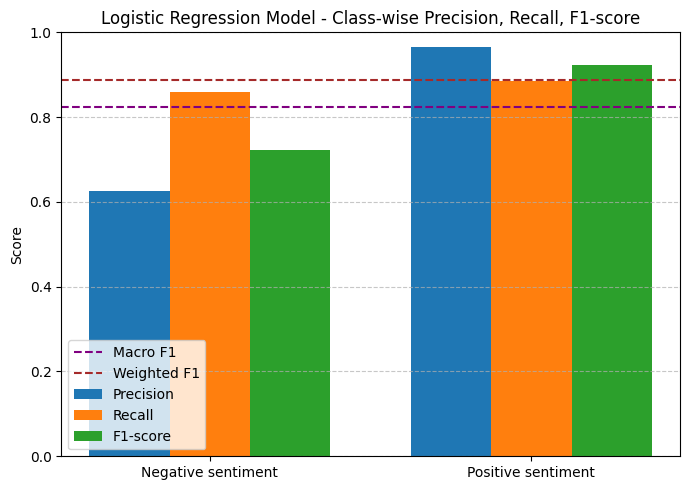

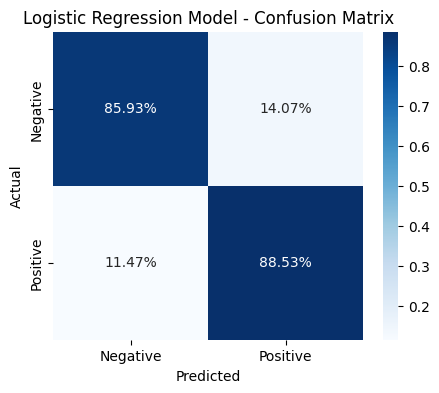

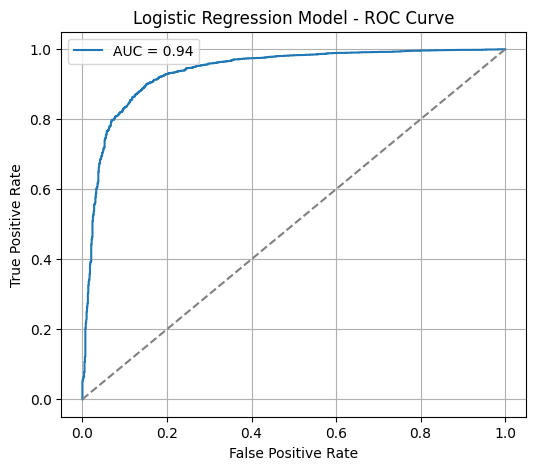

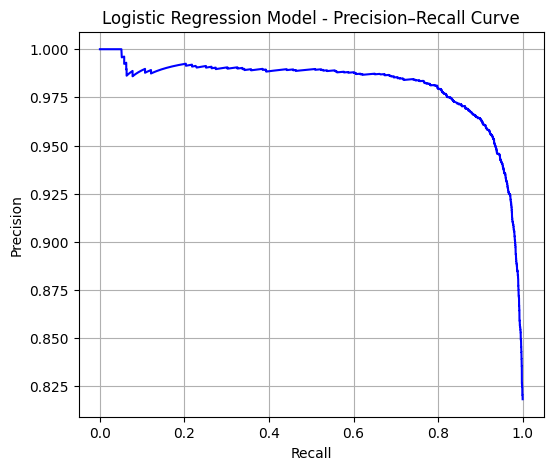


--- Linear SVM (Support Vector Machine) ---
                    precision    recall  f1-score   support

Negative sentiment       0.66      0.81      0.72      1009
Positive sentiment       0.95      0.91      0.93      4544

          accuracy                           0.89      5553
         macro avg       0.81      0.86      0.83      5553
      weighted avg       0.90      0.89      0.89      5553



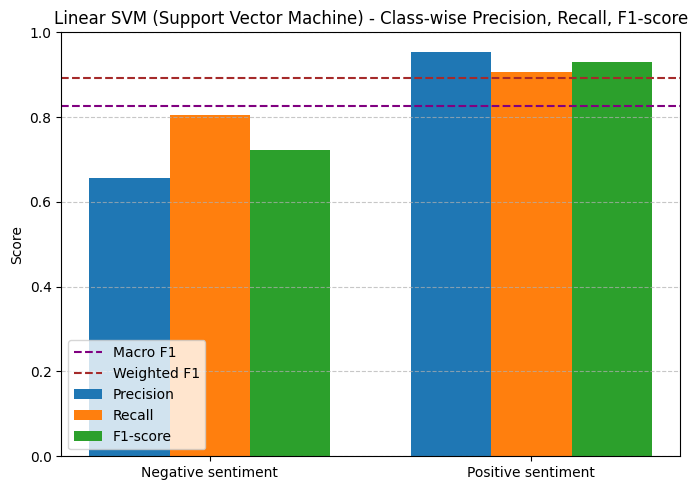

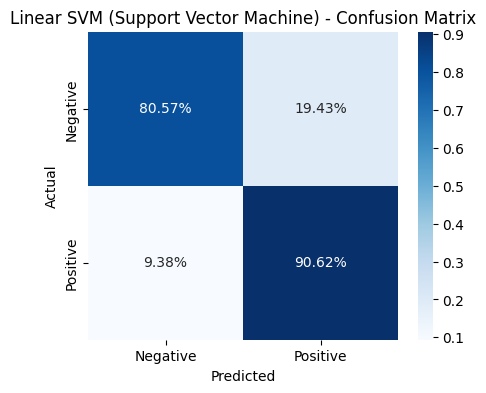

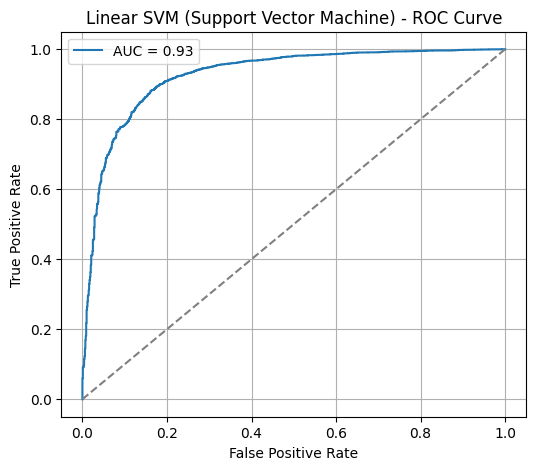

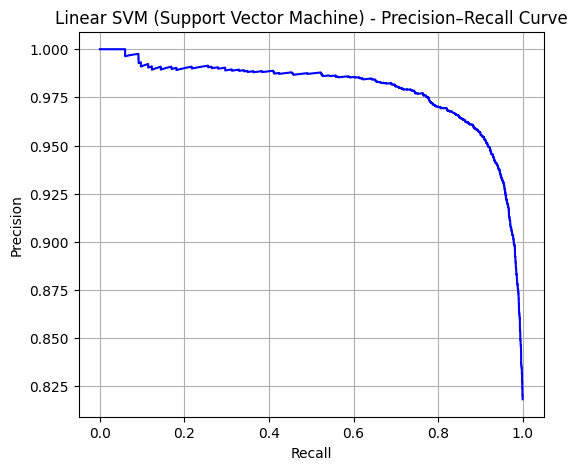


--- Complement Naive Bayes Model ---
                    precision    recall  f1-score   support

Negative sentiment       0.57      0.85      0.68      1009
Positive sentiment       0.96      0.86      0.91      4544

          accuracy                           0.86      5553
         macro avg       0.77      0.85      0.79      5553
      weighted avg       0.89      0.86      0.87      5553



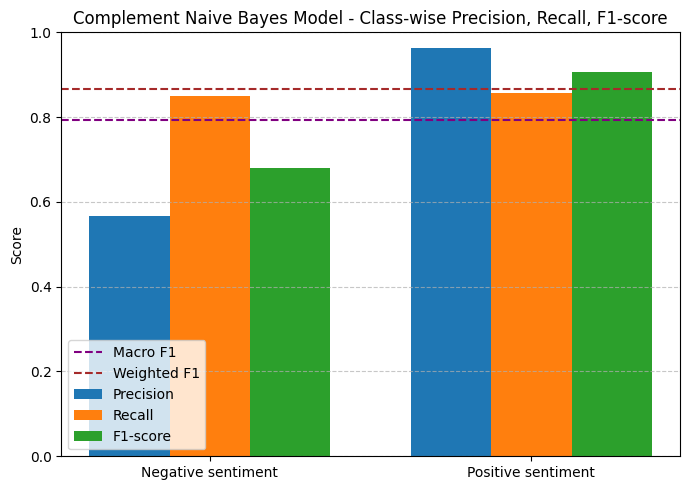

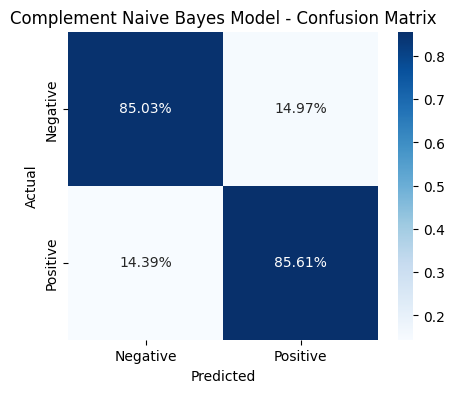

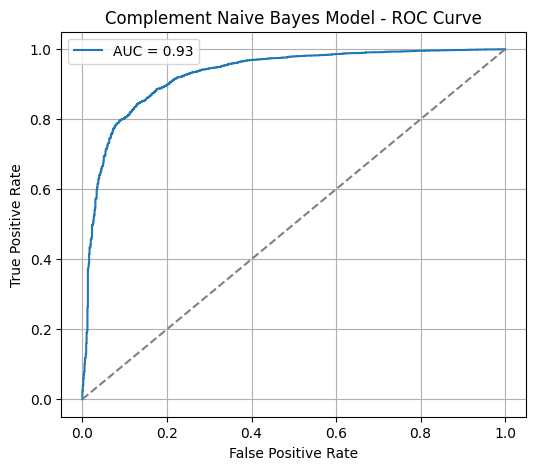

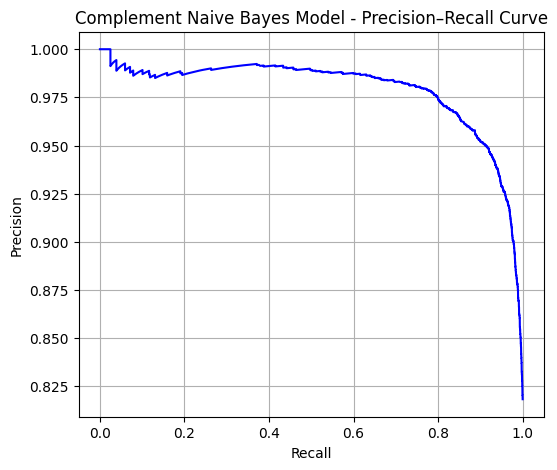


--- SGDClassifier Model ---
                    precision    recall  f1-score   support

Negative sentiment       0.62      0.86      0.72      1009
Positive sentiment       0.97      0.88      0.92      4544

          accuracy                           0.88      5553
         macro avg       0.79      0.87      0.82      5553
      weighted avg       0.90      0.88      0.89      5553



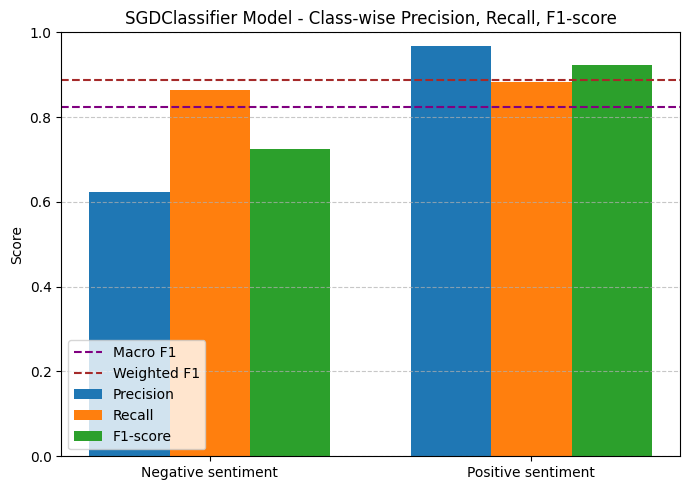

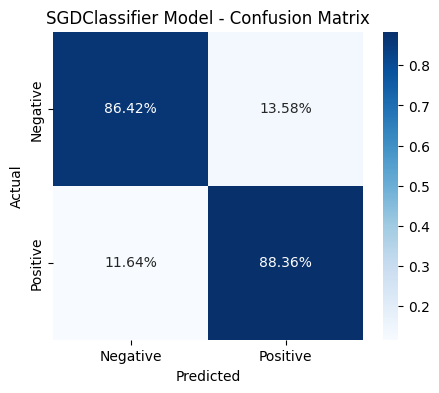

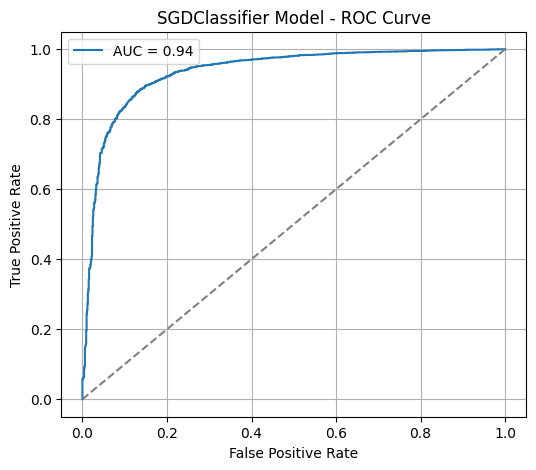

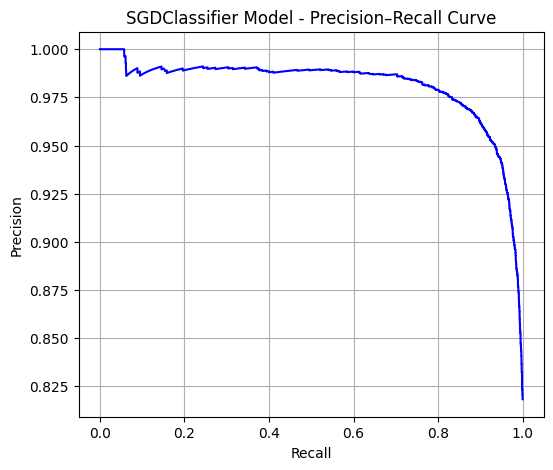

In [28]:
models_preds = {
    'Logistic Regression Model': y_pred_test_lr,
    'Linear SVM (Support Vector Machine)': y_pred_test_svm,
    'Complement Naive Bayes Model': y_pred_test_cnb,
    'SGDClassifier Model': y_pred_test_sgd,
}

models_trained = {
    'Logistic Regression Model': lr_model,
    'Linear SVM (Support Vector Machine)': svm_model,
    'Complement Naive Bayes Model': cnb_model,
    'SGDClassifier Model': sgd_model,
}

for model_name in models_preds.keys():
    y_pred = models_preds[model_name]
    trained_model = models_trained[model_name]
    
    print(f"\n--- {model_name} ---")
    
    ## 1. Classification Report
    print(classification_report(y_test, y_pred, target_names=['Negative sentiment', 'Positive sentiment']))
    
    ## 2. Bar Chart for Class-wise Precision/Recall/F1
    report = classification_report(y_test, y_pred, output_dict=True)
    classes = ['Negative sentiment', 'Positive sentiment']
    precision = [report['0']['precision'], report['1']['precision']]
    recall = [report['0']['recall'], report['1']['recall']]
    f1 = [report['0']['f1-score'], report['1']['f1-score']]
    macro_f1 = report['macro avg']['f1-score']
    weighted_f1 = report['weighted avg']['f1-score']

    x = np.arange(len(classes))
    width = 0.25

    fig, ax = plt.subplots(figsize=(7,5))
    ax.bar(x - width, precision, width, label='Precision', color='#1f77b4')
    ax.bar(x, recall, width, label='Recall', color='#ff7f0e')
    ax.bar(x + width, f1, width, label='F1-score', color='#2ca02c')
    ax.axhline(y=macro_f1, color='purple', linestyle='--', label='Macro F1')
    ax.axhline(y=weighted_f1, color='brown', linestyle='--', label='Weighted F1')
    ax.set_ylabel('Score')
    ax.set_title(f'{model_name} - Class-wise Precision, Recall, F1-score')
    ax.set_xticks(x)
    ax.set_xticklabels(classes)
    ax.set_ylim(0, 1.0)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    ## 3. Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, normalize='true')  # Normalizes rows to percentages
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.show()
    
    ## 4. ROC Curve + AUC
    try:
        # If model has predict_proba (like Logistic Regression, Naive Bayes)
        y_probs = trained_model.predict_proba(X_test_vec)[:,1]
    except AttributeError:
        # Use decision_function() for models without predict_proba (like SGDClassifier, SVM)
        y_probs = trained_model.decision_function(X_test_vec)
    
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0,1],[0,1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} - ROC Curve')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    ## 5. Precision–Recall Curve
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_probs)
    plt.figure(figsize=(6,5))
    plt.plot(recall_vals, precision_vals, color='blue')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{model_name} - Precision–Recall Curve')
    plt.grid(True)
    plt.show()

# Hyperparameter Tuning (RandomizedSearchCV)

## 1. Logistic Regression Model
### Parameters: C, l1_ratio

In [29]:
# Load model
logreg = LogisticRegression(solver='saga', penalty='elasticnet', max_iter=2000, class_weight='balanced')

# Hyperparameter Search Space
param_dist_logreg = {
    'C': loguniform(1e-3, 1e2), # continuous range
    'l1_ratio': uniform(0, 1)
}

# Cross Validation Strategy
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Randomized Search CV
random_logreg = RandomizedSearchCV(
    estimator=logreg,
    param_distributions=param_dist_logreg,
    n_iter=20,
    cv=cv_strategy,
    random_state=42,
    scoring='f1_macro', 
    n_jobs=-1,# Utilizing all available CPU cores
    verbose=4 # Detailed logging enabled
)

random_logreg.fit(X_train_vec, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 4/5] END C=0.0745934328572655, l1_ratio=0.9507143064099162;, score=0.727 total time=   0.6s
[CV 2/5] END C=4.5705630998014515, l1_ratio=0.5986584841970366;, score=0.820 total time=  31.9s
[CV 5/5] END C=4.5705630998014515, l1_ratio=0.5986584841970366;, score=0.811 total time=  33.9s
[CV 4/5] END C=14.528246637516036, l1_ratio=0.21233911067827616;, score=0.822 total time= 1.5min
[CV 3/5] END C=1.1462107403425035, l1_ratio=0.13949386065204183;, score=0.822 total time=  21.3s
[CV 1/5] END C=0.028888383623653185, l1_ratio=0.3663618432936917;, score=0.753 total time=   0.7s
[CV 2/5] END C=0.028888383623653185, l1_ratio=0.3663618432936917;, score=0.748 total time=   0.8s
[CV 5/5] END C=0.028888383623653185, l1_ratio=0.3663618432936917;, score=0.747 total time=   0.9s
[CV 2/5] END C=0.19069966103000435, l1_ratio=0.7851759613930136;, score=0.789 total time=   0.8s
[CV 5/5] END C=0.19069966103000435, l1_ratio=0.7851759613930136;,

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=LogisticRegression(class_weight='balanced',
                                                max_iter=2000,
                                                penalty='elasticnet',
                                                solver='saga'),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7ba647aa6360>,
                                        'l1_ratio': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7ba663624b60>},
                   random_state=42, scoring='f1_macro', verbose=4)

In [30]:
# Best results
print("Logistic Regression Model Best Parameters:")
print(random_logreg.best_params_)

print("Logistic Regression Model Best CV Scores:")
print(random_logreg.best_score_)

Logistic Regression Model Best Parameters:
{'C': np.float64(2.6373339933815254), 'l1_ratio': np.float64(0.4401524937396013)}
Logistic Regression Model Best CV Scores:
0.8224888397379836


In [31]:
# Test evaluation using best model
best_model_logreg = random_logreg.best_estimator_

y_pred_bm_logreg = best_model_logreg.predict(X_test_vec)

print("Best Logistic Regression Model Classification Report:")
print(classification_report(y_test, y_pred_bm_logreg))

# Top cross-validation result
results = pd.DataFrame(random_logreg.cv_results_)

print("Top 5 Logistic Regression Models:")
top_results = results.sort_values(by="rank_test_score").head(5)
print(top_results[['params', 'mean_test_score', 'std_test_score']])

Best Logistic Regression Model Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.85      0.73      1009
           1       0.96      0.90      0.93      4544

    accuracy                           0.89      5553
   macro avg       0.81      0.87      0.83      5553
weighted avg       0.91      0.89      0.89      5553

Top 5 Logistic Regression Models:
                                                         params  \
19    {'C': 2.6373339933815254, 'l1_ratio': 0.4401524937396013}   
10   {'C': 1.1462107403425035, 'l1_ratio': 0.13949386065204183}   
14  {'C': 0.9163741808778786, 'l1_ratio': 0.046450412719997725}   
15   {'C': 1.0907475835157696, 'l1_ratio': 0.17052412368729153}   
1     {'C': 4.5705630998014515, 'l1_ratio': 0.5986584841970366}   

    mean_test_score  std_test_score  
19         0.822489        0.006997  
10         0.819995        0.004751  
14         0.818806        0.004657  
15         0.818672        0.0

## 2. Linear SVM (Support Vector Machine)
### Parameters: C, loss

In [32]:
# Load model
svm = LinearSVC(max_iter=5000, class_weight='balanced')

# Hyperparameter Search Space
param_dist_svm = {
    'C': loguniform(1e-2, 1e1),
    'loss': ['hinge', 'squared_hinge']
}

# Cross Validation Strategy
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

random_svm = RandomizedSearchCV(
    estimator=svm,
    param_distributions=param_dist_svm,
    n_iter=20,
    cv=cv_strategy,
    random_state=42,
    scoring='f1_macro', 
    n_jobs=-1,# Utilizing all available CPU cores
    verbose=4 # Detailed logging enabled
)

random_svm.fit(X_train_vec, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=LinearSVC(class_weight='balanced', max_iter=5000),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7ba6471277d0>,
                                        'loss': ['hinge', 'squared_hinge']},
                   random_state=42, scoring='f1_macro', verbose=4)

In [33]:
# Best results
print("Linear SVM Best Parameters:")
print(random_svm.best_params_)

print("Linear SVM Best CV Scores:")
print(random_svm.best_score_)

Linear SVM Best Parameters:
{'C': np.float64(0.6251373574521749), 'loss': 'hinge'}
Linear SVM Best CV Scores:
0.8222316623778971


In [34]:
# Test evaluation using best model
best_model_svm = random_svm.best_estimator_

y_pred_bm_svm = best_model_svm.predict(X_test_vec)

print("Best Linear SVM Classification Report:")
print(classification_report(y_test, y_pred_bm_svm))

# Top cross-validation result
results = pd.DataFrame(random_svm.cv_results_)

print("Top 5 Linear SVM Models:")
top_results = results.sort_values(by="rank_test_score").head(5)
print(top_results[['params', 'mean_test_score', 'std_test_score']])

Best Linear SVM Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.86      0.73      1009
           1       0.97      0.89      0.93      4544

    accuracy                           0.88      5553
   macro avg       0.80      0.87      0.83      5553
weighted avg       0.90      0.88      0.89      5553

Top 5 Linear SVM Models:
                                                 params  mean_test_score  \
2            {'C': 0.6251373574521749, 'loss': 'hinge'}         0.822232   
11           {'C': 0.6838478430964046, 'loss': 'hinge'}         0.821871   
18  {'C': 0.34890188454913873, 'loss': 'squared_hinge'}         0.821095   
5   {'C': 0.10025956902289568, 'loss': 'squared_hinge'}         0.821021   
13           {'C': 0.3752528339573977, 'loss': 'hinge'}         0.819573   

    std_test_score  
2         0.005291  
11        0.004828  
18        0.004818  
5         0.003745  
13        0.004599  


## 3. Complement Naive Bayes Model
### Parameters: alpha, fit_prior, norm

In [35]:
# Load model
cnb = ComplementNB()

# Hyperparameter Search Space
param_dist_cnb = {
    'alpha': loguniform(1e-3, 10),
    'fit_prior': [True, False],
    'norm': [True, False]
}

# Cross Validation Strategy
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

random_cnb = RandomizedSearchCV(
    estimator=cnb,
    param_distributions=param_dist_cnb,
    n_iter=20,
    cv=cv_strategy,
    random_state=42,
    scoring='f1_macro', 
    n_jobs=-1,# Utilizing all available CPU cores
    verbose=4 # Detailed logging enabled
)

random_cnb.fit(X_train_vec, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=ComplementNB(), n_iter=20, n_jobs=-1,
                   param_distributions={'alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7ba6637da150>,
                                        'fit_prior': [True, False],
                                        'norm': [True, False]},
                   random_state=42, scoring='f1_macro', verbose=4)

In [36]:
# Best results
print("Complement Naive Bayes Model Best Parameters:")
print(random_cnb.best_params_)

print("Complement Naive Bayes Model CV Scores:")
print(random_cnb.best_score_)

Complement Naive Bayes Model Best Parameters:
{'alpha': np.float64(0.8471801418819978), 'fit_prior': True, 'norm': True}
Complement Naive Bayes Model CV Scores:
0.8159645896704495


In [37]:
# Test evaluation using best model
best_model_cnb = random_cnb.best_estimator_

y_pred_bm_cnb = best_model_cnb.predict(X_test_vec)

print("Best Complement Naive Bayes Model Classification Report:")
print(classification_report(y_test, y_pred_bm_cnb))

# Top cross-validation result
results = pd.DataFrame(random_cnb.cv_results_)

print("Top 5 Complement Naive Bayes Models:")
top_results = results.sort_values(by="rank_test_score").head(5)
print(top_results[['params', 'mean_test_score', 'std_test_score']])

Best Complement Naive Bayes Model Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.75      0.71      1009
           1       0.94      0.92      0.93      4544

    accuracy                           0.89      5553
   macro avg       0.81      0.84      0.82      5553
weighted avg       0.90      0.89      0.89      5553

Top 5 Complement Naive Bayes Models:
                                                              params  \
1     {'alpha': 0.8471801418819978, 'fit_prior': True, 'norm': True}   
6   {'alpha': 2.1368329072358767, 'fit_prior': False, 'norm': False}   
15   {'alpha': 0.26926469100861794, 'fit_prior': True, 'norm': True}   
4    {'alpha': 0.2537815508265665, 'fit_prior': False, 'norm': True}   
14   {'alpha': 0.23423849847112907, 'fit_prior': True, 'norm': True}   

    mean_test_score  std_test_score  
1          0.815965        0.009599  
6          0.814839        0.007302  
15         0.807694        0.005

## 4. SGDClassifier Model
### Parameters: loss, penalty, alpha

In [38]:
# Load model
sgd = SGDClassifier(max_iter=2000, tol=1e-3, loss='hinge', class_weight='balanced', penalty='elasticnet')

# Hyperparameter Search Space
param_dist_sgd = {
    'alpha': loguniform(1e-5, 1e-2),
    'l1_ratio': uniform(0, 1)
}

# Cross Validation Strategy
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Randomized Search CV
random_sgd = RandomizedSearchCV(
    estimator=sgd,
    param_distributions=param_dist_sgd,
    n_iter=20,
    cv=cv_strategy,
    random_state=42,
    scoring='f1_macro', 
    n_jobs=-1,# Utilizing all available CPU cores
    verbose=4 # Detailed logging enabled
)

random_sgd.fit(X_train_vec, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 2/5] END C=0.0745934328572655, l1_ratio=0.9507143064099162;, score=0.757 total time=   0.7s
[CV 3/5] END C=4.5705630998014515, l1_ratio=0.5986584841970366;, score=0.823 total time=  32.8s
[CV 3/5] END C=0.006026889128682512, l1_ratio=0.15599452033620265;, score=0.734 total time=   0.6s
[CV 5/5] END C=0.006026889128682512, l1_ratio=0.15599452033620265;, score=0.719 total time=   0.6s
[CV 2/5] END C=0.0019517224641449498, l1_ratio=0.8661761457749352;, score=0.154 total time=   0.2s
[CV 5/5] END C=0.0019517224641449498, l1_ratio=0.8661761457749352;, score=0.450 total time=   0.1s
[CV 2/5] END C=1.0129197956845732, l1_ratio=0.7080725777960455;, score=0.815 total time=   5.4s
[CV 5/5] END C=1.0129197956845732, l1_ratio=0.7080725777960455;, score=0.808 total time=   4.4s
[CV 3/5] END C=14.528246637516036, l1_ratio=0.21233911067827616;, score=0.817 total time= 1.5min
[CV 3/5] END C=0.14445251022763064, l1_ratio=0.29122914019804

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=SGDClassifier(class_weight='balanced',
                                           max_iter=2000,
                                           penalty='elasticnet'),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7ba646b9e8a0>,
                                        'l1_ratio': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7ba647b0c260>},
                   random_state=42, scoring='f1_macro', verbose=4)

In [39]:
# Best results
print("SGDClassifier Model Best Parameters:")
print(random_sgd.best_params_)

print("SGDClassifier Model CV Scores:")
print(random_sgd.best_score_)

SGDClassifier Model Best Parameters:
{'alpha': np.float64(8.200518402245828e-05), 'l1_ratio': np.float64(0.09767211400638387)}
SGDClassifier Model CV Scores:
0.8200764150422403


In [40]:
# Test evaluation using best model
best_model_sgd = random_sgd.best_estimator_

y_pred_bm_sgd = best_model_sgd.predict(X_test_vec)

print("Best SGDClassifier Model Classification Report:")
print(classification_report(y_test, y_pred_bm_sgd))

# Top cross-validation result
results = pd.DataFrame(random_sgd.cv_results_)

print("Top 5 SGDClassifier Model Models:")
top_results = results.sort_values(by="rank_test_score").head(5)
print(top_results[['params', 'mean_test_score', 'std_test_score']])

Best SGDClassifier Model Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.86      0.73      1009
           1       0.97      0.89      0.92      4544

    accuracy                           0.88      5553
   macro avg       0.80      0.87      0.83      5553
weighted avg       0.90      0.88      0.89      5553

Top 5 SGDClassifier Model Models:
                                                               params  \
18  {'alpha': 8.200518402245828e-05, 'l1_ratio': 0.09767211400638387}   
11    {'alpha': 7.52374288453485e-05, 'l1_ratio': 0.3663618432936917}   
13   {'alpha': 3.972110727381908e-05, 'l1_ratio': 0.5142344384136116}   
8     {'alpha': 8.17949947521167e-05, 'l1_ratio': 0.5247564316322378}   
7   {'alpha': 3.511356313970405e-05, 'l1_ratio': 0.18340450985343382}   

    mean_test_score  std_test_score  
18         0.820076        0.006353  
11         0.817549        0.006864  
13         0.816633        0.006417  


## Best Models Result Visualization 


--- Logistic Regression Model ---
                    precision    recall  f1-score   support

Negative sentiment       0.65      0.85      0.73      1009
Positive sentiment       0.96      0.90      0.93      4544

          accuracy                           0.89      5553
         macro avg       0.81      0.87      0.83      5553
      weighted avg       0.91      0.89      0.89      5553



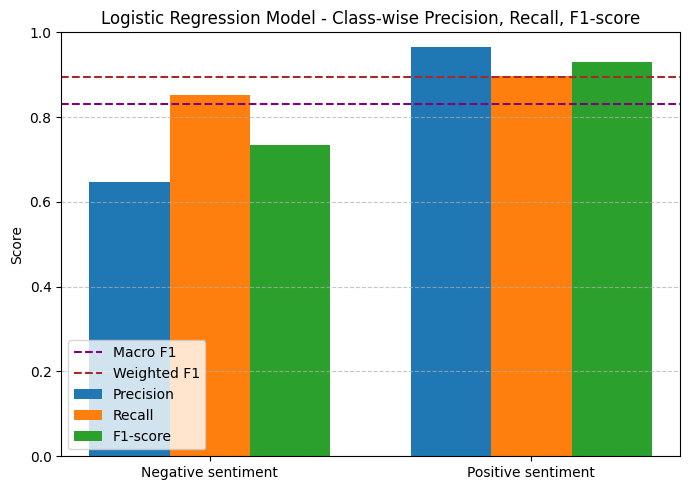

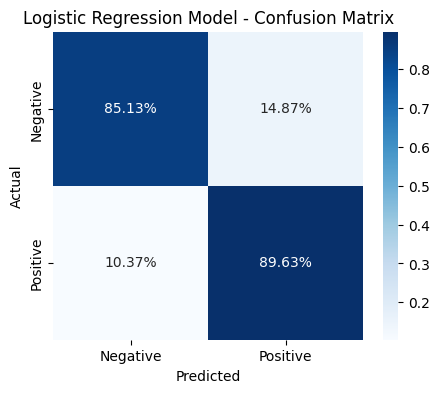

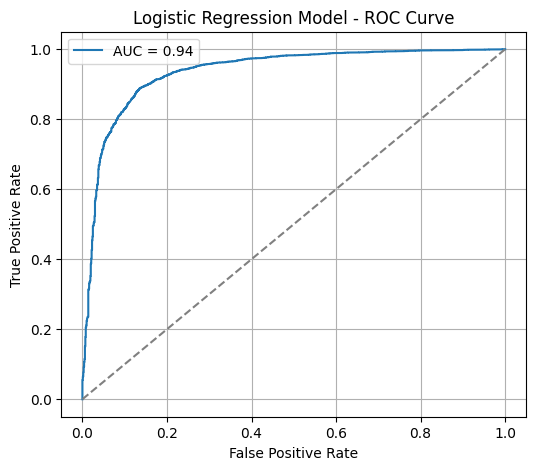

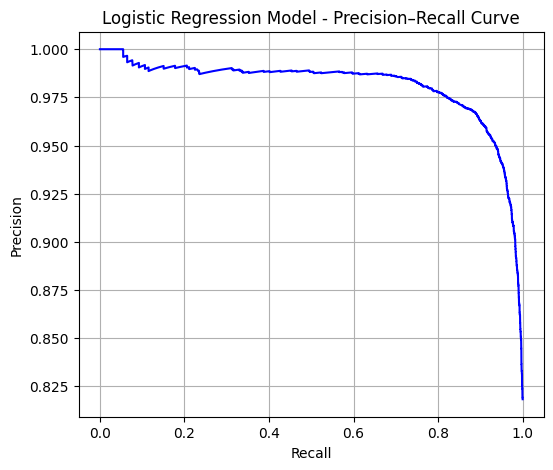


--- Linear SVM (Support Vector Machine) ---
                    precision    recall  f1-score   support

Negative sentiment       0.63      0.86      0.73      1009
Positive sentiment       0.97      0.89      0.93      4544

          accuracy                           0.88      5553
         macro avg       0.80      0.87      0.83      5553
      weighted avg       0.90      0.88      0.89      5553



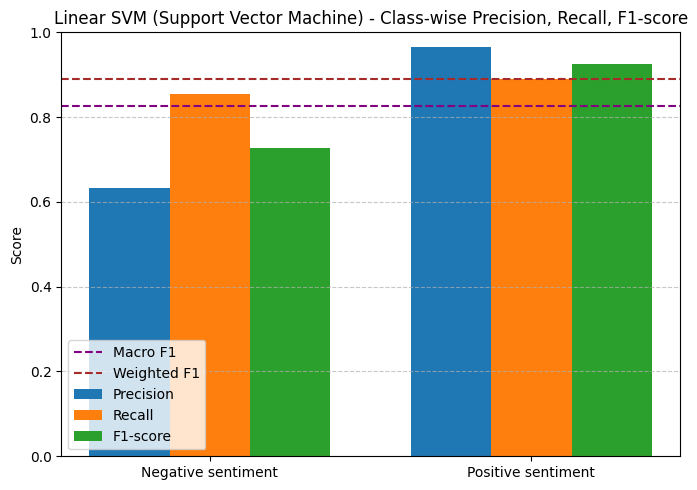

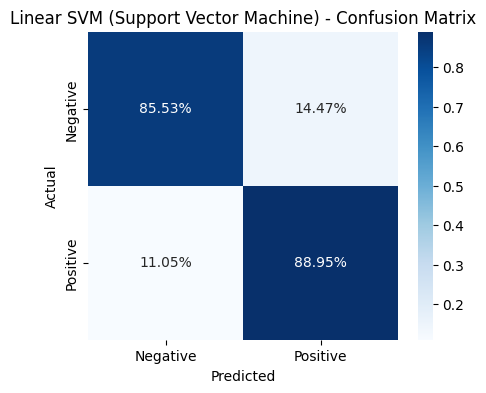

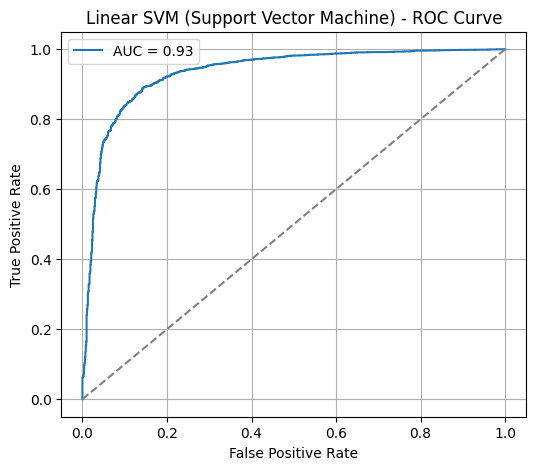

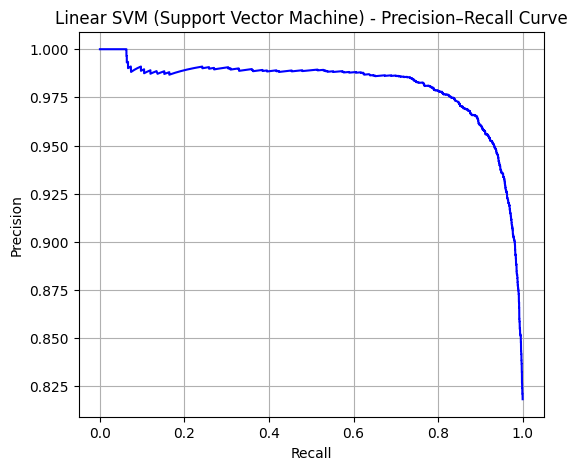


--- Complement Naive Bayes Model ---
                    precision    recall  f1-score   support

Negative sentiment       0.68      0.75      0.71      1009
Positive sentiment       0.94      0.92      0.93      4544

          accuracy                           0.89      5553
         macro avg       0.81      0.84      0.82      5553
      weighted avg       0.90      0.89      0.89      5553



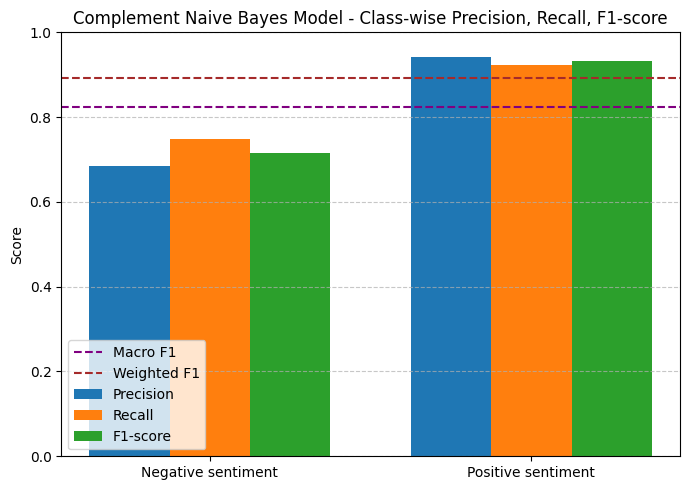

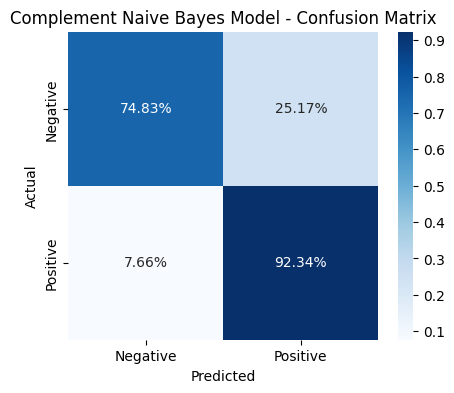

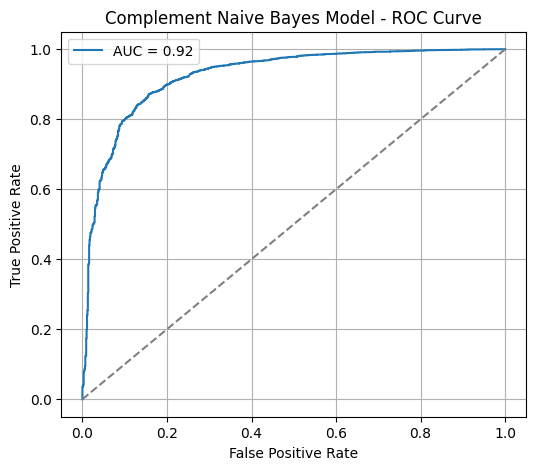

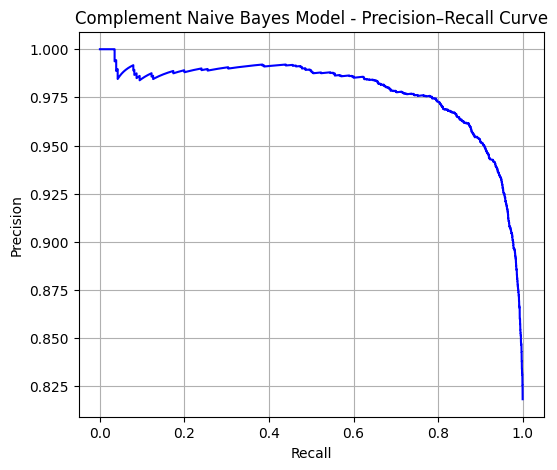


--- SGDClassifier Model ---
                    precision    recall  f1-score   support

Negative sentiment       0.63      0.86      0.73      1009
Positive sentiment       0.97      0.89      0.92      4544

          accuracy                           0.88      5553
         macro avg       0.80      0.87      0.83      5553
      weighted avg       0.90      0.88      0.89      5553



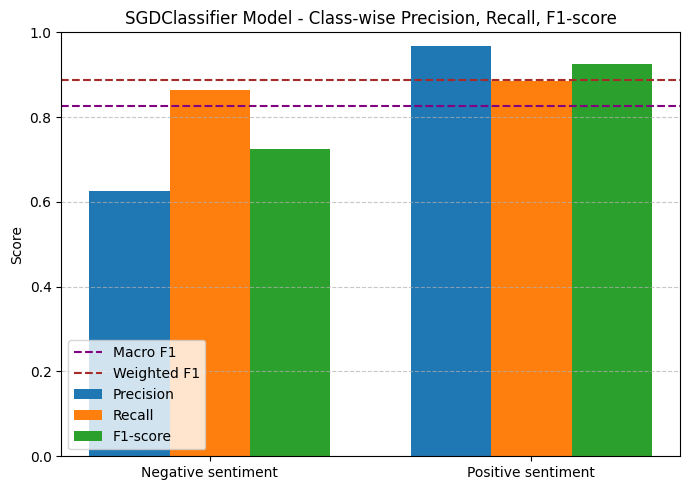

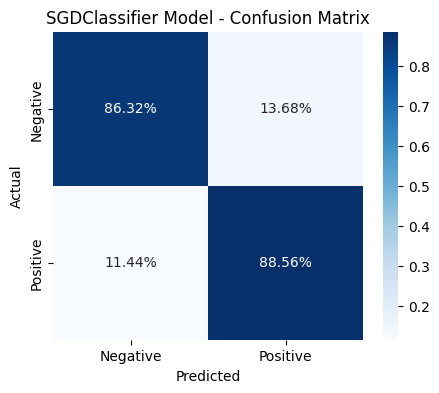

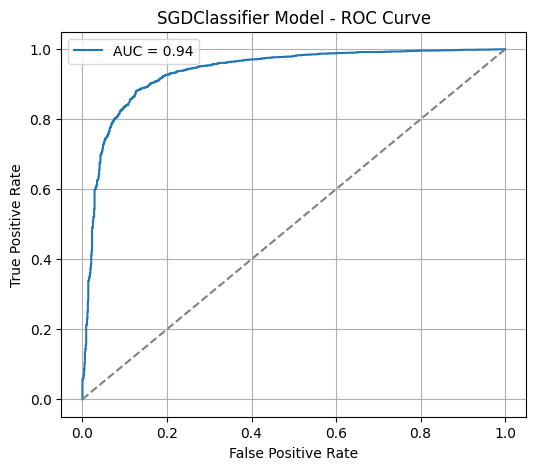

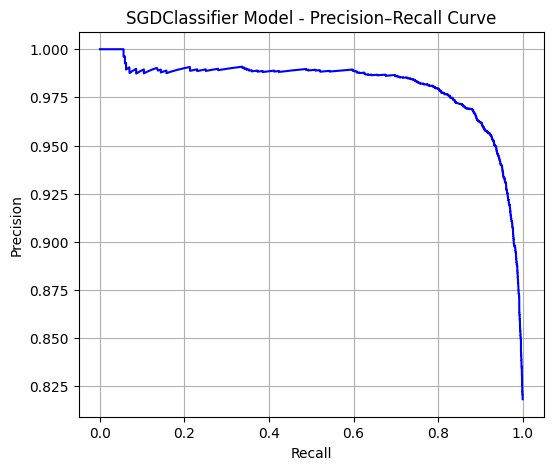

In [41]:
models_preds = {
    'Logistic Regression Model': y_pred_bm_logreg,
    'Linear SVM (Support Vector Machine)': y_pred_bm_svm,
    'Complement Naive Bayes Model': y_pred_bm_cnb,
    'SGDClassifier Model': y_pred_bm_sgd,
}

models_trained = {
    'Logistic Regression Model': best_model_logreg,
    'Linear SVM (Support Vector Machine)': best_model_svm,
    'Complement Naive Bayes Model': best_model_cnb,
    'SGDClassifier Model': best_model_sgd,
}

for model_name in models_preds.keys():
    y_pred = models_preds[model_name]
    trained_model = models_trained[model_name]
    
    print(f"\n--- {model_name} ---")
    
    ## 1. Classification Report
    print(classification_report(y_test, y_pred, target_names=['Negative sentiment', 'Positive sentiment']))
    
    ## 2. Bar Chart for Class-wise Precision/Recall/F1
    report = classification_report(y_test, y_pred, output_dict=True)
    classes = ['Negative sentiment', 'Positive sentiment']
    precision = [report['0']['precision'], report['1']['precision']]
    recall = [report['0']['recall'], report['1']['recall']]
    f1 = [report['0']['f1-score'], report['1']['f1-score']]
    macro_f1 = report['macro avg']['f1-score']
    weighted_f1 = report['weighted avg']['f1-score']

    x = np.arange(len(classes))
    width = 0.25

    fig, ax = plt.subplots(figsize=(7,5))
    ax.bar(x - width, precision, width, label='Precision', color='#1f77b4')
    ax.bar(x, recall, width, label='Recall', color='#ff7f0e')
    ax.bar(x + width, f1, width, label='F1-score', color='#2ca02c')
    ax.axhline(y=macro_f1, color='purple', linestyle='--', label='Macro F1')
    ax.axhline(y=weighted_f1, color='brown', linestyle='--', label='Weighted F1')
    ax.set_ylabel('Score')
    ax.set_title(f'{model_name} - Class-wise Precision, Recall, F1-score')
    ax.set_xticks(x)
    ax.set_xticklabels(classes)
    ax.set_ylim(0, 1.0)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    ## 3. Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, normalize='true')  # Normalizes rows to percentages
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.show()
    
    ## 4. ROC Curve + AUC
    try:
        # If model has predict_proba (like Logistic Regression, Naive Bayes)
        y_probs = trained_model.predict_proba(X_test_vec)[:,1]
    except AttributeError:
        # Use decision_function() for models without predict_proba (like SGDClassifier, SVM)
        y_probs = trained_model.decision_function(X_test_vec)
    
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0,1],[0,1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} - ROC Curve')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    ## 5. Precision–Recall Curve
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_probs)
    plt.figure(figsize=(6,5))
    plt.plot(recall_vals, precision_vals, color='blue')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{model_name} - Precision–Recall Curve')
    plt.grid(True)
    plt.show()